<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/twyncoder/tf-handson-tcb/blob/main/L04_IntroCNN_clasificacionMulticlase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Redes de Aprendizaje Profundo básicas con Keras y Tensorflow.
## *Convolutional Deep Neural Networks (CNN) para clasificación multi-clase*

# 0. Preparación del entorno y comprobación de requisitos

In [1]:
# Common imports
import os
import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
from tensorflow import keras

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_name, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_name + "." + fig_extension)
    print("Saving figure", fig_name)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def print_history(history,title=None, extension='png'):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    #plt.gca().set_ylim(0, 1)
    plt.xlabel("epochs")
    if(title!=None):
        plt.title(title)
        save_fig(title,fig_extension=extension)

### Información de versiones

In [2]:
print(tf.__version__)

2.10.1


### Comprobar si disponemos de una GPU

In [3]:
tf.config.list_physical_devices('GPU')

[]

# 1. Dataset

In [4]:
from numpy import load
data = load('bloodmnist.npz')
X_train_orig = data['train_images']
X_valid_orig = data['val_images']
X_test_orig = data['test_images']
Y_train = data['train_labels']
Y_valid = data['val_labels']
Y_test = data['test_labels']

A continuación se dispone de las etiquetas de las clases a las que pueden pertenecer las imágenes.

In [5]:
labels = ["basophil","eosinophil","erythroblast","immature granulocytes", # clasificación multiclase
          "lymphocyte","monocyte","neutrophil","platelet"]

**¡AHORA TÚ!**
- Averigua las dimensiones de los datos de entrada proporcionados en el dataset
- Escribe una función para mostrar ejemplos de la base de datos con su etiqueta correspondiente y llámala desde la celda de más abajo

In [6]:
print(X_train_orig.shape)
print(X_valid_orig.shape)
print(X_test_orig.shape)

(11959, 28, 28, 3)
(1712, 28, 28, 3)
(3421, 28, 28, 3)


In [7]:
# 11959 imágenes de entrenamiento de tamaño 28x28 y con 3 canales cada una
# 1712 imágenes de validación "                                          "
# 3421 imágenes de test "                                                "

#### IMPORTANTE !!! 

- IMAGENES EN BLANCO Y NEGRO: 1 CANAL

- IMAGENES EN COLOR: 3 CANALES (RGB)

In [8]:
X_train_orig.dtype

dtype('uint8')

In [9]:
Y_train

array([[7],
       [3],
       [6],
       ...,
       [1],
       [6],
       [4]], dtype=uint8)

In [10]:
def show_example(x,y):
    plt.imshow(x, cmap="binary")
    plt.axis('off')
    plt.show()
    print(labels[y])

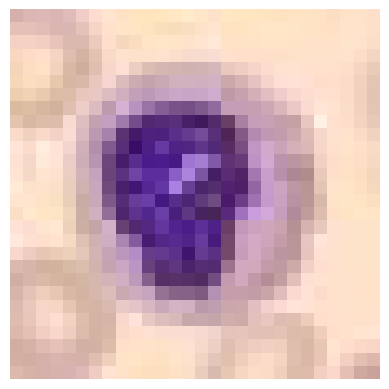

neutrophil


In [11]:
N = 5
show_example(X_train_orig[N],Y_train[N][0])

### Estandarización de las entradas

In [12]:
X_mean = X_train_orig.mean(axis=0, keepdims=True)
X_std = X_train_orig.std(axis=0, keepdims=True) + 1e-7

X_train = (X_train_orig - X_mean) / X_std
X_valid = (X_valid_orig - X_mean) / X_std
X_test = (X_test_orig - X_mean) / X_std

**¡AHORA TÚ!**
- Observa las dimensiones de `X_mean` y `X_std` con `.shape` y explica cómo se está haciendo la estandarización de los datos de entrada a la red.
- Observa que `X_mean` y `X_std` se calculan sobre el set de entrenamiento, pero después se aplican también para **pseudo estandarizar** el set de validación y el set de test, ¿puedes explicar por qué no se calculan `X_mean` y `X_std` sobre todas las imágenes disponibles y solamente sobre el set de entrenamiento?.

In [13]:
X_mean.shape

(1, 28, 28, 3)

In [14]:
X_std.shape

(1, 28, 28, 3)

Estas dimensiones indican que:

- 1: Se mantiene una dimensión extra (batch) para facilitar la operación de broadcasting.

- 28 x 28: Cada imagen tiene dimensiones espaciales de 28 píxeles por 28 píxeles.

- 3: Corresponde a las 3 canales de color (RGB), lo que es típico en imágenes a color.

#### Explicación de la estandarización

La estandarización se realiza restando la media (X_mean) y dividiendo por la desviación estándar (X_std) para cada píxel y cada canal de color, asegurando que cada característica (píxel) tenga una media cercana a 0 y una desviación estándar cercana a 1. Esto mejora la convergencia del entrenamiento en redes neuronales al asegurar que todas las entradas estén en una escala similar.
 
#### ¿Por qué se calcula sobre el conjunto de entrenamiento?

- Evitar el sesgo por fuga de datos: Si calcularamos X_mean y X_std utilizando todo el conjunto de datos (incluyendo validación y test), estaríamos filtrando información del conjunto de prueba hacia el modelo, introduciendo un sesgo y comprometiendo la evaluación independiente del modelo.

- Simulación de datos futuros: El conjunto de validación y test representan datos nuevos o futuros. En la práctica real, solo se dispondrá de estadísticas del conjunto de entrenamiento para preprocesar nuevos datos.

- Generalización del modelo: Calcular los parámetros de estandarización solo en el conjunto de entrenamiento permite evaluar cómo el modelo generaliza a datos no vistos, utilizando las mismas transformaciones que aplicaría a nuevos datos.

# 2. Entrenamiento

## Modelo 'base' de red neuronal

In [15]:
model1 = keras.models.Sequential()

model1.add(keras.layers.Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(28, 28, 3)))
model1.add(keras.layers.MaxPooling2D((2, 2))) # realiza un diezmado / submuestreo de la entrada quedandose con el maximo de cada cuarto de mapa

model1.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model1.add(keras.layers.Flatten())

model1.add(keras.layers.Dense(32, activation='relu'))
model1.add(keras.layers.Dense(8, activation='softmax')) # hay 8 clases

**¡AHORA TÚ!**
- En base a la anterior definición de red neuronal:
  - Añade el valor adecuado en <<<FIXME>>>
  - Busca información sobre `keras.layers.Conv2D()` y averigua qué quiere decir `padding='same'`. ¿Qué otra opción existe para este parámetro y qué implicaciones tiene usarla?
  - ¿Cuántos _feature maps_ o `channels` se generan a la salida de la primera capa? ¿de qué tamaño son los `kernels` de convolución?
  - ¿Eres capaz de intuir cuáles serán las dimensiones de los _feature maps_ después de realizar el primer _pooling_?


In [16]:
help(keras.layers.Conv2D)

Help on class Conv2D in module keras.layers.convolutional.conv2d:

class Conv2D(keras.layers.convolutional.base_conv.Conv)
 |  Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', data_format=None, dilation_rate=(1, 1), groups=1, activation=None, use_bias=True, kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=None, bias_regularizer=None, activity_regularizer=None, kernel_constraint=None, bias_constraint=None, **kwargs)
 |  
 |  2D convolution layer (e.g. spatial convolution over images).
 |  
 |  This layer creates a convolution kernel that is convolved
 |  with the layer input to produce a tensor of
 |  outputs. If `use_bias` is True,
 |  a bias vector is created and added to the outputs. Finally, if
 |  `activation` is not `None`, it is applied to the outputs as well.
 |  
 |  When using this layer as the first layer in a model,
 |  provide the keyword argument `input_shape`
 |  (tuple of integers or `None`, does not include the sample axis),

- ("same" results in padding with zeros evenly to the left/right or up/down of the input)

El argumento padding='same' en la capa Conv2D asegura que la salida de la convolución tenga las mismas dimensiones espaciales que la entrada. Esto se logra añadiendo ceros alrededor de los bordes de la imagen para compensar la reducción de tamaño que normalmente ocurre con la convolución.

- (la otra opción: "valid" means no padding)

padding='valid': No se añade ningún padding, lo que reduce las dimensiones de salida. El tamaño de la salida disminuye en función del tamaño del kernel.

Implicaciones:
- same: Mantiene las dimensiones espaciales constantes al agregarse padding, por lo que no se pierde información de los bordes.
- valid: Reduce las dimensiones espaciales, ya que no se agrega padding, perdiéndose información.

#### Feature maps generados y tamaño de los kernels
- Feature maps o canales generados por la primera capa Conv2D:
La primera capa Conv2D genera 16 feature maps. Esto se especifica en el argumento filters=16.

- Tamaño de los kernels de convolución:
El tamaño de los kernels es (3, 3), definido por kernel_size=(3, 3).

#### Dimensiones de los feature maps después del primer MaxPooling2D
Antes del pooling, las dimensiones son las mismas que la entrada, gracias a padding='same':

- Dimensiones entrada a MaxPooling2D: (28,28,16)

El pooling usa una ventana de tamaño (2, 2) con paso (stride) de 2, lo que reduce las DIMENSIONES ESPACIALES a la mitad:

- Dimensiones después de pooling: (28/2,28/2,16)=(14,14,16)

**¡AHORA TÚ!**
- Obtén un `summary()` de la red anterior responde a las siguientes cuestiones:
   - Asegúrate de entender cómo disminuye el tamaño de las capas en `height` y `width` desde 28x28 px a la entrada hasta 7x7 después de la última capa de _pooling_.
   - ¿Cuántos parámetros entrenables tiene la red? Compara esta cifra con el número de parámetros de los modelos _fully connected_ de cuadernos anteriores. ¡Estamos creando una red con menos parámetros y esperamos que se comporte mejor!
   - ¿Eres capaz de explicar el número de parámetros entrenables de alguna de las capas?
   - Puedes probar a cambiar la configuración de `model1` y ver cómo afecta a los tamaños y número de capas.

In [17]:
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1568)              0         
                                                                 
 dense (Dense)               (None, 32)                5

Tiene 55.560 parámetros entrenables, las redes fully connected tenian unos 250.000 parámetros

#### Reducción de tamaño de las capas (height y width)
La reducción en las dimensiones espaciales (height y width) sigue un patrón predecible:

- Entrada inicial: (28, 28, 3)
- Primera convolución (Conv2D): (28, 28, 16) (no cambia debido a padding='same')
- Primer pooling (MaxPooling2D): (14, 14, 16) (reduce a la mitad por pool_size=(2, 2))
- Segunda convolución (Conv2D): (14, 14, 32) (mantiene dimensiones por padding='same')
- Segundo pooling (MaxPooling2D): (7, 7, 32) (nuevamente reduce a la mitad)

En resumen, el tamaño se reduce con cada MaxPooling2D debido al tamaño de la ventana (2, 2), dividiendo cada dimensión espacial entre 2.

#### Parámetros entrenables totales de la red
La red tiene un total de 55,560 parámetros entrenables.

- Comparación con modelos fully connected:
En redes completamente conectadas (fully connected), el número de parámetros es mucho mayor porque cada neurona está conectada a todas las neuronas de la capa anterior. Aquí, el uso de capas convolucionales reduce drásticamente los parámetros al compartir pesos a través de los kernels.

#### Explicación del número de parámetros en algunas capas
- Primera capa Conv2D (16 filtros, kernel 3x3):

Parámetros=(3x3x3+1)x16=448 

- Segunda capa Conv2D (32 filtros, kernel 3x3):

Parámetros=(3x3x16+1)x32=4640

- Capa Dense (1568 entradas, 32 salidas):

Parámetros=(1568+1)x32=50208

- Capa final Dense (32 entradas, 8 salidas):

Parámeros=(32+1)x8=264

(los +1 son por los bias)

#### Conclusión
- La red tiene 55,560 parámetros entrenables, significativamente menos que modelos fully connected con un número similar de neuronas.
- La disminución en height y width se debe al uso de MaxPooling2D.
- El uso de capas convolucionales permite una reducción de parámetros manteniendo la capacidad de extraer características relevantes.

**¡AHORA TÚ!**
- Entrena la red neuronal durante 15 epochs con un optimizador `adam`
- Ve observando durante el entrenamiento los resultados de `acc` y `val_acc`

In [19]:
model1.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(),
              metrics=["accuracy"])

In [20]:
history = model1.fit(X_train, Y_train, epochs=15,
                    validation_data=(X_valid, Y_valid))

Epoch 1/15
374/374 [==============================] - 10s 22ms/step - loss: 0.6582 - accuracy: 0.7647 - val_loss: 0.4195 - val_accuracy: 0.8516
Epoch 2/15
374/374 [==============================] - 7s 19ms/step - loss: 0.3713 - accuracy: 0.8670 - val_loss: 0.3641 - val_accuracy: 0.8692
Epoch 3/15
374/374 [==============================] - 7s 20ms/step - loss: 0.2872 - accuracy: 0.8984 - val_loss: 0.3149 - val_accuracy: 0.8954
Epoch 4/15
374/374 [==============================] - 8s 21ms/step - loss: 0.2389 - accuracy: 0.9142 - val_loss: 0.2846 - val_accuracy: 0.8989
Epoch 5/15
374/374 [==============================] - 7s 20ms/step - loss: 0.2017 - accuracy: 0.9250 - val_loss: 0.2371 - val_accuracy: 0.9060
Epoch 6/15
374/374 [==============================] - 7s 19ms/step - loss: 0.1633 - accuracy: 0.9426 - val_loss: 0.3148 - val_accuracy: 0.8890
Epoch 7/15
374/374 [==============================] - 7s 19ms/step - loss: 0.1461 - accuracy: 0.9471 - val_loss: 0.2990 - val_accuracy: 0.894

**¡AHORA TÚ!**
- Muestra una gráfica la evolución del entrenamiento
  - ¿Se produce _overfitting_ durante el entrenamiento? Si es así, ¿a partir de qué _epoch_ aproximadamente?

In [21]:
pdhist = pd.DataFrame(history.history)

In [22]:
pdhist.head() # head imprime las primeras posiciones

,loss,accuracy,val_loss,val_accuracy
0,0.658180,0.764696,0.419500,0.851636
1,0.371286,0.867046,0.364115,0.869159
2,0.287214,0.898403,0.314942,0.895444
3,0.238863,0.914207,0.284613,0.898949
4,0.201660,0.924994,0.237069,0.905958


Saving figure T01_mnist_simple_dnn


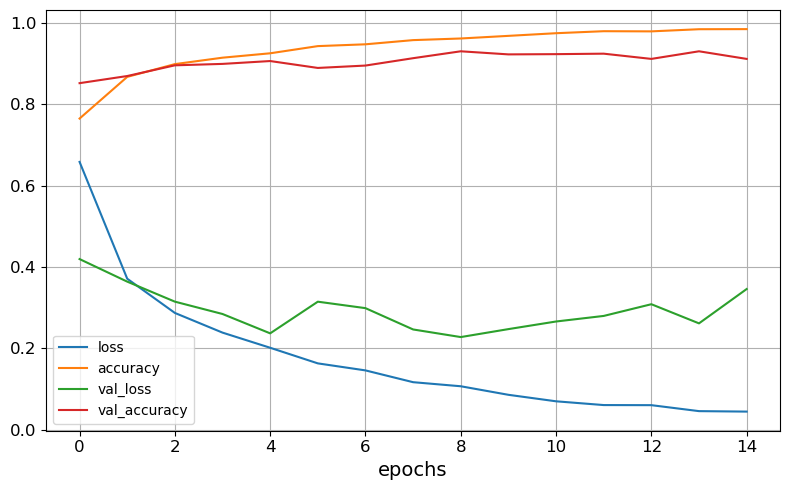

In [23]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

La pérdida en el conjunto de entrenamiento sigue bajando y se estabiliza en un valor bajo, pero la pérdida de validación empieza a aumentar después de un cierto número de épocas, esto indica que el modelo está aprendiendo demasiado sobre los datos de entrenamiento, lo que lleva al sobreajuste.

- Overfitting:
Parece que sí hay señales de overfitting, ya que a partir de aproximadamente la Epoch 9:

    - La pérdida de validación deja de disminuir significativamente y comienza a aumentar.
    - La precisión de validación se estabiliza, mientras que la precisión de entrenamiento sigue mejorando.
- Epoch crítica:
Aproximadamente desde la Epoch 9 o 10, el modelo empieza a mostrar signos de que está memorizando los datos de entrenamiento más que generalizando bien a los datos de validación.

Posibles causas

- Modelo demasiado complejo: Si el modelo tiene muchas capas o parámetros, puede estar memorizando los datos en lugar de aprender patrones generalizables.
- Insuficiente regularización: La falta de técnicas como dropout, L2, o batch normalization puede permitir que el modelo se ajuste demasiado a los datos de entrenamiento.
- Cantidad de datos limitada: Si el conjunto de entrenamiento no es suficientemente grande o representativo, el modelo puede sobreajustar fácilmente.

## Batch Normalization

Vamos a incorporar capas de `BatchNormalization()` a nuestro modelo.
- Llámalo esta vez `model2`
- Batch Normalization actúa como técnica de regularización.
- Prueba a introducirlo entre las capas de convolución y _pooling_ y en la penúltima capa _fully connected_
- **No** debes incluir las activaciones en la capa anterior a `BatchNormalization()` **pero debes** incluir una capa de activación en la capa siguiente.
- ¿Cuántos parámetros entrenables y no entrenables se han añadido a la red?
- **No entrenes la red todavía**

In [24]:
model2 = keras.models.Sequential()

model2.add(keras.layers.Conv2D(16, kernel_size=(3, 3), activation= None, padding='same', input_shape=(28, 28, 3)))
model2.add(keras.layers.BatchNormalization()) # batchnormalization entre las capas de convolución y pooling
model2.add(keras.layers.Activation("relu")) # capa de activación en la capa siguiente al batchnormalization
model2.add(keras.layers.MaxPooling2D((2, 2)))

model2.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation= None, padding='same'))
model2.add(keras.layers.BatchNormalization()) # batchnormalization entre las capas de convolución y pooling
model2.add(keras.layers.Activation("relu")) # capa de activación en la capa siguiente al batchnormalization
model2.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model2.add(keras.layers.Flatten())
model2.add(keras.layers.Dense(32, activation='relu'))
model2.add(keras.layers.BatchNormalization()) # batchnormalization en la penúltima capa fully connected
model2.add(keras.layers.Dense(8, activation='softmax'))

In [25]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 28, 28, 16)        448       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 16)       64        
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 28, 28, 16)        0         
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 16)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 batch_normalization_1 (Batc  (None, 14, 14, 32)      

Ahora tenemos además parámetros no entrenables (media y desviación estandar) debido al batchnormalization.

## Early Stopping

- Parar el entrenamiento es una forma de prevenir que la red sobreentrene y también de no gastar tiempo de cómputo innecesariamente.
- Se puede dejar a la red que siga entrenando durante un tiempo, pero utilizar después en la etapa de inferencia los parámetros que proporcionaron el menor `val_loss` o la mejor `val_acc` (distintos de los de la última _epoch_).

In [26]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,verbose=1) #PERMITIR 3 EPOCAS SIN MEJORA
model_checkpoint_cb = keras.callbacks.ModelCheckpoint("model2.keras", save_best_only=True)

El parámetro patience en la función de callback EarlyStopping de Keras indica cuántas épocas adicionales se entrenará el modelo sin que haya mejora en la métrica de monitoreo (por ejemplo, la pérdida de validación, val_loss) antes de detener el entrenamiento de manera anticipada.

**¡AHORA TÚ!**
- Vamos a entrenar la red `model2` durante 15 _epochs_ y a guardar los resultados del entrenamiento en una variable `history2`
- Para el entrenamiento, incluye los _callbacks_ `early_stopping_cb` y `model_checkpoint_cb` tal y como los hemos definido arriba. Para ejecutar varios _callback_ simultáneamente recuerda que puedes hacer una lista con corchetes en la llamada en la función `fit()`.
- Mientras se realiza el entrenamiento revisa información sobre `EarlyStopping()` y `ModelCheckpoint()`.
   - https://keras.io/api/callbacks/early_stopping/
   - https://keras.io/api/callbacks/model_checkpoint/


In [27]:
model2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(),
              metrics=["accuracy"])

In [28]:
history2 = model2.fit(X_train, Y_train, epochs=15,
                    validation_data=(X_valid, Y_valid),
                    batch_size=32,
                    callbacks=[early_stopping_cb, model_checkpoint_cb])

Epoch 1/15
374/374 [==============================] - 14s 33ms/step - loss: 0.5656 - accuracy: 0.8126 - val_loss: 0.4661 - val_accuracy: 0.8189
Epoch 2/15
374/374 [==============================] - 11s 29ms/step - loss: 0.3131 - accuracy: 0.8960 - val_loss: 0.3147 - val_accuracy: 0.8867
Epoch 3/15
374/374 [==============================] - 11s 29ms/step - loss: 0.2485 - accuracy: 0.9177 - val_loss: 0.2690 - val_accuracy: 0.9065
Epoch 4/15
374/374 [==============================] - 10s 28ms/step - loss: 0.1989 - accuracy: 0.9313 - val_loss: 0.2329 - val_accuracy: 0.9200
Epoch 5/15
374/374 [==============================] - 10s 28ms/step - loss: 0.1711 - accuracy: 0.9426 - val_loss: 0.3387 - val_accuracy: 0.8861
Epoch 6/15
374/374 [==============================] - 10s 28ms/step - loss: 0.1392 - accuracy: 0.9523 - val_loss: 0.3161 - val_accuracy: 0.9013
Epoch 7/15
374/374 [==============================] - 10s 27ms/step - loss: 0.1245 - accuracy: 0.9561 - val_loss: 0.2434 - val_accuracy:

**¡AHORA TÚ!**
- Finalizado el entrenamiento, representa un gráfico con la evolución de la red y a continuación, responde a las siguientes preguntas:
  - ¿En qué _epoch_ se ha parado el entrenamiento?
  - ¿En qué _epoch_ se obtenía el menor _val_loss_?
  - ¿Los parámetros de qué epoch se han salvado en 'model2.keras'?

Saving figure T01_mnist_simple_dnn


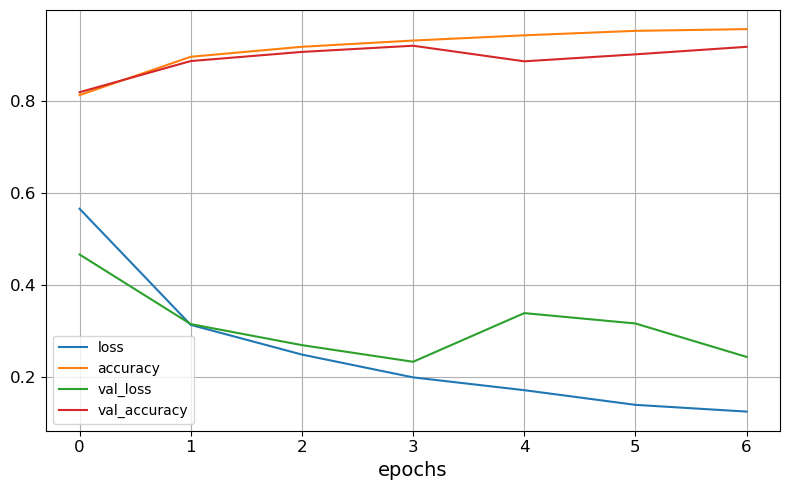

In [29]:
pd.DataFrame(history2.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

- ¿En qué epoch se ha parado el entrenamiento?

El entrenamiento se ha detenido en la Epoch 7, como indica el mensaje Epoch 7: early stopping.

- ¿En qué epoch se obtenía el menor val_loss?

El menor val_loss se obtuvo en la Epoch 4, con un valor de 0.2329.

- ¿Los parámetros de qué epoch se han salvado en 'model2.keras'?

Los parámetros guardados corresponden a la epoch 4, ya que ModelCheckpoint almacena el modelo con el menor val_loss observado hasta ese punto.

## Variación dinámica del learning rate
- Una forma de prevenir el sobreentrenamiento es ir disminuyendo de manera dinámica el _learning rate_. De hecho, algunos optimizadores lo hacen internamente de manera automática.
- Entre las estrategias más utilizadas encontramos _Reduce on plateau_, que consiste en añadir un _callback_ para que se reduzca el `learning_rate` cuando el _loss_ se queda en una meseta.

In [30]:
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.4, patience=2,verbose=1)

**¡AHORA TÚ!**
- Vamos a volver a entrenar modelo `model1` (sin _Batch Normalization_) o `model2`, pero esta vez variando el _learning rate_ dinámicamente.
- Vuelve a definir el modelo y llámalo `model3`

In [31]:
model3 = keras.models.Sequential()

model3.add(keras.layers.Conv2D(16, kernel_size=(3, 3), activation= None, padding='same', input_shape=(28, 28, 3)))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation("relu"))
model3.add(keras.layers.MaxPooling2D((2, 2)))

model3.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation= None, padding='same'))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation("relu"))
model3.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model3.add(keras.layers.Flatten())

model3.add(keras.layers.Dense(32, activation='relu'))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Dense(8, activation='softmax'))

**¡AHORA TÚ!**
- Añade el _callback_ `lr_scheduler` durante el entrenamiento, junto con  `model_checkpoint_cb`.
- Opcionalmente puedes añadir el callback `early_stopping_cb`, pero si el entrenamiento para demasido pronto y no se disminuye el _learning_rate_ y quieras quitarlo para poder observar bien el efecto de `lr_scheduler`.
- Para no sobreescribir `model2.h5` será mejor que vuelvas a definir `model_checkpoint_cb` e incluir esta vez `model3.keras`.
- Lanza un entrenamiento con al menos 20 epochs y empleando el siguiente optimizador
- Mientras se realiza revisa información sobre `EarlyStopping()`.
   - https://keras.io/api/callbacks/reduce_lr_on_plateau/
- Grafica los resultados y compara con entrenamientos anteriores

In [32]:
model_checkpoint_cb = keras.callbacks.ModelCheckpoint("model3.keras", save_best_only=True)

In [33]:
model3.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

In [34]:
history3 = model3.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid),
                    batch_size=32,
                    callbacks=[early_stopping_cb, model_checkpoint_cb, lr_scheduler])

Epoch 1/20
374/374 [==============================] - 13s 30ms/step - loss: 0.5729 - accuracy: 0.8099 - val_loss: 0.4037 - val_accuracy: 0.8575 - lr: 0.0010
Epoch 2/20
374/374 [==============================] - 10s 28ms/step - loss: 0.3177 - accuracy: 0.8919 - val_loss: 0.4405 - val_accuracy: 0.8540 - lr: 0.0010
Epoch 3/20
374/374 [==============================] - 10s 27ms/step - loss: 0.2438 - accuracy: 0.9185 - val_loss: 0.3301 - val_accuracy: 0.8919 - lr: 0.0010
Epoch 4/20
374/374 [==============================] - 10s 27ms/step - loss: 0.1960 - accuracy: 0.9333 - val_loss: 0.2827 - val_accuracy: 0.9065 - lr: 0.0010
Epoch 5/20
374/374 [==============================] - 10s 27ms/step - loss: 0.1662 - accuracy: 0.9419 - val_loss: 0.3038 - val_accuracy: 0.8879 - lr: 0.0010
Epoch 6/20
374/374 [==============================] - 11s 28ms/step - loss: 0.1420 - accuracy: 0.9492 - val_loss: 0.2425 - val_accuracy: 0.9188 - lr: 0.0010
Epoch 7/20
374/374 [==============================] - 11s 

Saving figure T01_mnist_simple_dnn


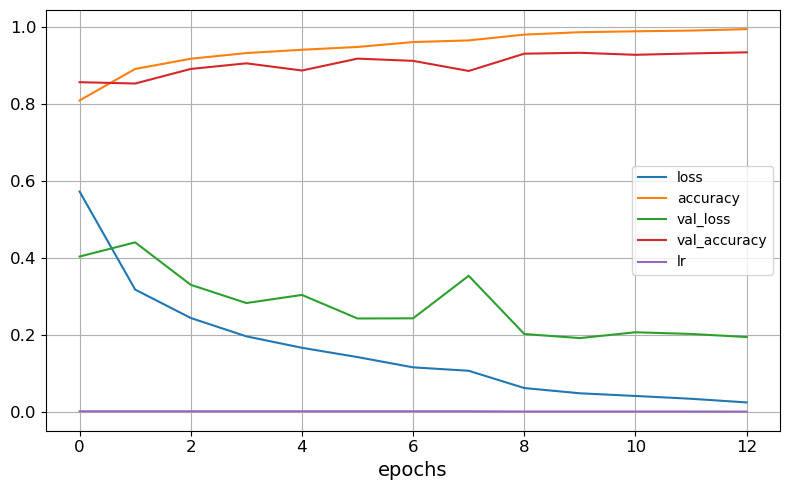

In [35]:
pd.DataFrame(history3.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

- El entrenamiento se detuvo en la epoch 13, como indica la línea:
Epoch 13: early stopping.

- Reducción del learning rate (LR):

    - En la Epoch 8, el LR se redujo a 0.0004.
    - En la Epoch 12, el LR se redujo a 0.00016.

- Modelo guardado:
Los parámetros guardados en 'model3.keras' corresponden al mejor val_loss, que ocurrió en la Epoch 10 con un val_loss de 0.1915.

#### Análisis del uso de ReduceLROnPlateau:
1. ¿Qué hace ReduceLROnPlateau?
Este callback reduce la tasa de aprendizaje cuando una métrica (como val_loss) deja de mejorar.

2. Comparación con entrenamientos anteriores:

- Reducción del learning rate (lr_scheduler):

    - En este entrenamiento, ReduceLROnPlateau ajustó dinámicamente la tasa de aprendizaje. Se observa que después de la Epoch 8 y la Epoch 12, el learning_rate se redujo, lo que permitió una mejora en la estabilidad del val_loss.
    - La pérdida de validación (val_loss) alcanzó valores bajos sin sobreajuste marcado, lo que sugiere que el ajuste del learning_rate fue beneficioso para evitar un descenso abrupto seguido de un incremento.
- Mejor precisión de validación:

    - La precisión de validación (val_accuracy) alcanzó un 93.5% en la Epoch 13, mostrando una mejora respecto a los entrenamientos anteriores.
    - En comparación con los entrenamientos previos, donde hubo fluctuaciones mayores, la reducción controlada del learning_rate logró estabilizar la precisión.

- Early stopping:

    - En este caso, se activó en la Epoch 13, lo cual es posterior al entrenamiento anterior (Epoch 7). Esto indica que la reducción del learning_rate permitió mejorar la generalización antes de detener el entrenamiento.
- Pérdida de validación:

    - La pérdida de validación (val_loss) bajó a 0.1915 en la Epoch 10, uno de los valores más bajos logrados hasta ahora.
    - En los entrenamientos previos, val_loss no mostró tanta consistencia después de las primeras epochs.

#### Conclusión:
El uso de lr_scheduler permitió una mejor convergencia, redujo las oscilaciones de pérdida y mejoró la generalización. Comparado con el entrenamiento previo, donde early_stopping detuvo antes, este permitió llegar más lejos ajustando gradualmente la tasa de aprendizaje.

## Dropout
- Puedes introducir capas de Dropout de la siguiente manera.

`keras.layers.Dropout(rate=...)`

**¡AHORA TÚ!**
- Crea un nuevo modelo `model4` añadiendo capas de dropout  después de las capas de _pooling_ en `model2`. Puedes probar con valores de `rate=0.25` por ejemplo.
- Lanza un entrenamiento de al menos 20 _epochs_ y con _Early Stopping_ y que guarde los pesos en `model4.keras`. Utiliza un valor de `epochs` y `patience` acorde a las capacidades de procesamiento de tu ordenador. Si es lento no pongas valores elevados. El valor de `patience` en el callback que reduce el _learning_rate_ deberá ser mayor que en callback que hace el _model_checkpoint_.
- Durante el mismo busca información sobre las capas `Dropout` y el parámetro `rate`.
- Grafica nuevamente los resultados y compara el entrenamiento con los modelos anteriores
- Por último, si el entrenamiento no se hubiera parado en la última _epoch_, salva los resultados con `model4.save("model4.keras")`

In [37]:
# DEFINE MODEL

model4 = keras.models.Sequential()

model4.add(keras.layers.Conv2D(16, kernel_size=(3, 3), activation= None, padding='same', input_shape=(28, 28, 3)))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation("relu"))
model4.add(keras.layers.MaxPooling2D((2, 2)))
model4.add(keras.layers.Dropout(0.25))  # Dropout después de MaxPooling

model4.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation= None, padding='same'))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation("relu"))
model4.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model4.add(keras.layers.Dropout(0.25))  # Dropout después de MaxPooling

model4.add(keras.layers.Flatten())

model4.add(keras.layers.Dense(32, activation='relu'))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Dense(8, activation='softmax'))

In [39]:
# COMPILE MODEL

model4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

In [41]:
# CALLBACKS

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5,verbose=1)
model_checkpoint_cb = keras.callbacks.ModelCheckpoint("model4.keras", save_best_only=True)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=1)

In [42]:
# FIT MODEL

history4 = model4.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid),
                    batch_size=32,
                    callbacks=[early_stopping_cb, model_checkpoint_cb, lr_scheduler])

Epoch 1/20
374/374 [==============================] - 14s 33ms/step - loss: 0.7337 - accuracy: 0.7517 - val_loss: 0.5211 - val_accuracy: 0.8032 - lr: 0.0010
Epoch 2/20
374/374 [==============================] - 12s 32ms/step - loss: 0.4423 - accuracy: 0.8471 - val_loss: 0.3522 - val_accuracy: 0.8785 - lr: 0.0010
Epoch 3/20
374/374 [==============================] - 11s 30ms/step - loss: 0.3762 - accuracy: 0.8704 - val_loss: 0.3135 - val_accuracy: 0.8931 - lr: 0.0010
Epoch 4/20
374/374 [==============================] - 11s 30ms/step - loss: 0.3305 - accuracy: 0.8844 - val_loss: 0.3198 - val_accuracy: 0.8785 - lr: 0.0010
Epoch 5/20
374/374 [==============================] - 12s 32ms/step - loss: 0.3154 - accuracy: 0.8894 - val_loss: 0.2503 - val_accuracy: 0.9141 - lr: 0.0010
Epoch 6/20
374/374 [==============================] - 11s 30ms/step - loss: 0.2912 - accuracy: 0.8991 - val_loss: 0.2616 - val_accuracy: 0.9071 - lr: 0.0010
Epoch 7/20
374/374 [==============================] - 12s 

Saving figure T01_mnist_simple_dnn


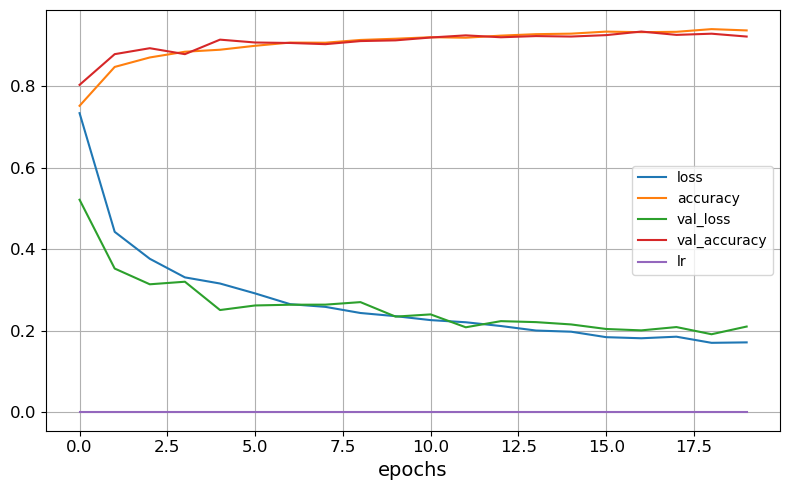

In [43]:
# PLOT HISTORY

pd.DataFrame(history4.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

#### Análisis y Comparación del Entrenamiento con Dropout en model4:
- Adición de capas Dropout:

En este modelo, se añadieron capas de Dropout(0.25) después de cada capa de MaxPooling. Esto introduce una regularización para reducir el riesgo de sobreajuste, especialmente en las capas convolucionales, permitiendo que la red generalice mejor al eliminar conexiones durante el entrenamiento de manera aleatoria.
El valor de rate=0.25 significa que el 25% de las unidades en esas capas serán "apagadas" durante cada paso de entrenamiento, ayudando a que el modelo no dependa demasiado de ningún nodo en particular.
- Evolución de la precisión:

En las primeras epochs, la precisión de validación (val_accuracy) sube de manera consistente y alcanza un 92.4% en la Epoch 12.
A partir de la Epoch 19, la precisión de validación comienza a estabilizarse. Aunque el valor sigue siendo alto, no hay una mejora sustancial, lo que podría indicar que el modelo ya ha aprendido lo suficiente con los datos disponibles.

- Evolución de la pérdida de validación:

La pérdida de validación (val_loss) disminuye progresivamente a lo largo de las primeras 14 epochs, llegando a un mínimo de 0.1909 en la Epoch 19. Sin embargo, al final de la última epoch (Epoch 20), la pérdida de validación vuelve a aumentar a 0.2098, lo que podría indicar un leve sobreajuste.
- Comportamiento del learning rate:

A lo largo del entrenamiento, el learning rate se mantiene constante en 0.001, ya que no se ha activado el callback ReduceLROnPlateau. Esto sugiere que el modelo no muestra una mejora suficiente en la validación como para requerir un ajuste en la tasa de aprendizaje.
- Early Stopping y Model Checkpoint:

El callback EarlyStopping no activó su detención temprana, ya que el modelo no mostró estancamientos en el rendimiento de validación.
El modelo guardó los pesos en el archivo "model4.keras" durante el entrenamiento gracias al callback ModelCheckpoint.
#### Comparación con modelos anteriores:
- Mejora en la generalización: Al añadir las capas de Dropout, el modelo parece haber mejorado en términos de generalización, ya que la pérdida de validación se mantiene relativamente baja sin fluctuar demasiado, lo que sugiere que las capas de regularización están funcionando bien.
- Estabilidad: Comparado con el modelo anterior (model3), donde el learning rate se redujo dinámicamente, este modelo muestra un comportamiento más estable sin variaciones drásticas. El modelo parece haber aprendido correctamente a partir de los datos sin caer en sobreajuste, pero la tasa de aprendizaje constante pudo haber limitado un poco el potencial de mejora posterior.
- Rendimiento: Aunque la precisión de validación es similar o incluso ligeramente superior en este modelo en comparación con los modelos anteriores, los valores de val_loss no mejoraron mucho después de la Epoch 14, lo que puede ser una indicación de que el modelo ha alcanzado su límite de aprendizaje en las condiciones actuales.
#### Conclusión:
El modelo con Dropout muestra un buen rendimiento sin sobreajustarse, pero es posible que un ajuste dinámico del learning rate o un aumento en las epochs hubiera permitido una mejor convergencia. Comparado con los entrenamientos anteriores, este modelo es más robusto gracias a la regularización, pero su rendimiento en las últimas épocas sugiere que podría beneficiarse de ajustes adicionales en la tasa de aprendizaje o en los hiperparámetros.

## 3. Test
**¡AHORA TÚ!**
- Carga alguno de los modelos salvados anteriormente y evalúalo (usando `evaluate()`), sobre las muestras reservadas para test.
- A continuación:
  - Evalúa el modelo sobre el set de test empleando `evaluate()`
  - En otra celda genera predicciones con `predict()` sobre **todo el subconjunto de test**.

In [44]:
#TODO EVALUATE MODEL

model4.evaluate(X_test, Y_test)

107/107 [==============================] - 1s 12ms/step - loss: 0.2309 - accuracy: 0.9170


[0.2308959811925888, 0.9169833660125732]

In [47]:
#TODO PREDICT

y_pred = model4.predict(X_test)

# Mostrar las predicciones redondeadas
print("Predicciones redondeadas:", y_pred.round(2))

# Mostrar las clases predichas (la clase con mayor probabilidad)
print("Clases predichas:", np.argmax(y_pred, axis=-1))

# Si deseas comparar las predicciones con las etiquetas verdaderas
print("Etiquetas verdaderas:", Y_test)

107/107 [==============================] - 1s 13ms/step
Predicciones redondeadas: [[0.   0.   0.02 ... 0.14 0.   0.  ]
 [0.89 0.08 0.   ... 0.01 0.   0.  ]
 [0.   0.95 0.   ... 0.   0.05 0.  ]
 ...
 [0.   0.   0.   ... 0.01 0.   0.  ]
 [0.   0.99 0.   ... 0.   0.01 0.  ]
 [0.   0.   0.   ... 0.   0.   1.  ]]
Clases predichas: [3 0 1 ... 3 1 7]
Etiquetas verdaderas: [[3]
 [0]
 [1]
 ...
 [3]
 [1]
 [7]]


Ha acertado todas las predicciones correctamente :)

### Matriz de confusión
**¡AHORA TÚ!**
- Utiliza las predicciones anteriores para generar un matriz de confusión normalizada y otra sin normalizar.
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

In [48]:
y_true = Y_test
y_pred = np.argmax(y_pred, axis=-1)

In [49]:
confnorm = confusion_matrix(y_true, y_pred,normalize='true')

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of ticklabels (10).

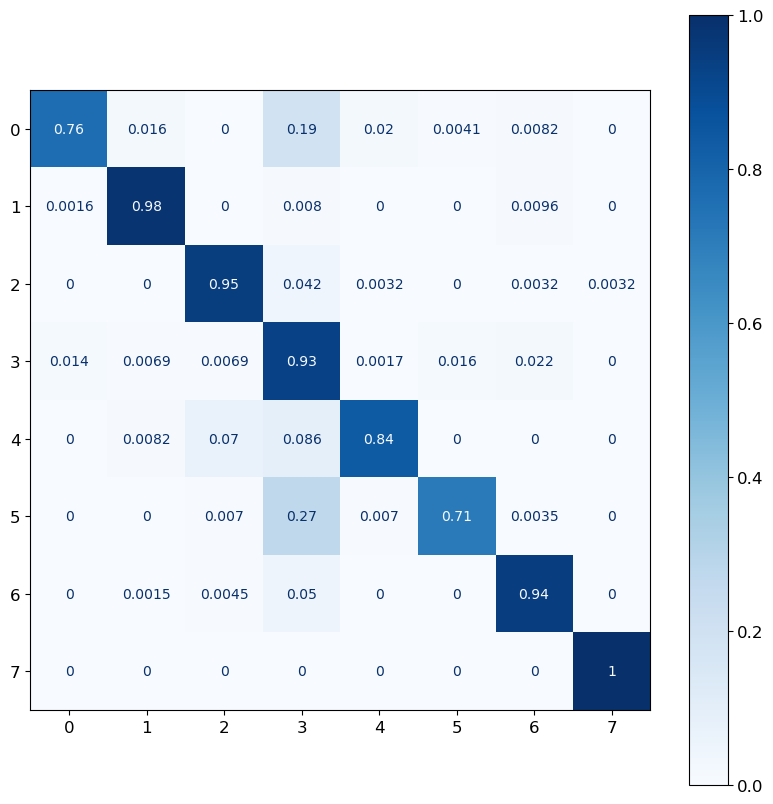

In [51]:
disp = ConfusionMatrixDisplay(confusion_matrix=confnorm,
                                display_labels=labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

In [53]:
confnonorm = confusion_matrix(y_true, y_pred,normalize=None)

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of ticklabels (10).

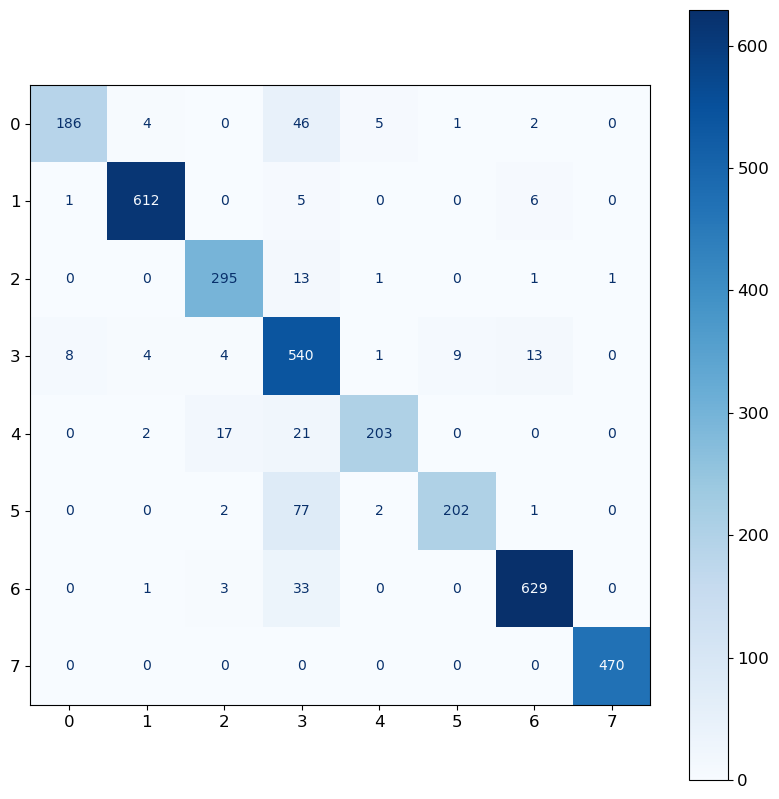

In [54]:
disp = ConfusionMatrixDisplay(confusion_matrix=confnonorm,
                                display_labels=labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

### Métricas de rendimiento

**¡AHORA TÚ!**
- Observa cómo podemos obtener los TP,TN,FP y FN a partir de la matriz de confusión `conf`.
- Revisa el significado de estas variables y entiende cómo se han obtenido a partir de `conf`. ¿Por qué estas variables se expresan en forma de vectores en lugar de valores escalares?

In [56]:
TP = np.diag(confnorm) # COGE LA DIAGONAL
FP = confnorm.sum(axis=0) - TP # FILAS
FN = confnorm.sum(axis=1) - TP # COLUMNAS
TN = confnorm.sum() - (FP + FN + TP) # EL RESTO
FP = FP.astype(float)
FN = FN.astype(float)
TP = TP.astype(float)
TN = TN.astype(float)

**¡AHORA TÚ!**
- Calcula e imprime la métrica F1-score para cada clase y su valor medio.
- ¿Cuáles son las clases con las mejores/peores métricas F1-score?
- Prueba a calcular e imprimir también las métricas _Accuracy_, _Sensitivity_ y _Specificity_.

In [59]:
# F1-score por clase
f1_scores = 2 * TP / (2 * TP + FP + FN)
print("F1-score por clase:")
for i, f1 in enumerate(f1_scores):
    print(f"Clase {i}: {f1:.4f}")

# F1-score promedio (media)
f1_score_avg = np.mean(f1_scores)
print(f"\nF1-score promedio: {f1_score_avg:.4f}")

# Accuracy por clase
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("\nAccuracy por clase:")
for i, acc in enumerate(accuracy):
    print(f"Clase {i}: {acc:.4f}")

# Sensitivity por clase (Recall)
sensitivity = TP / (TP + FN)
print("\nSensitivity (Recall) por clase:")
for i, sens in enumerate(sensitivity):
    print(f"Clase {i}: {sens:.4f}")

# Specificity por clase
specificity = TN / (TN + FP)
print("\nSpecificity por clase:")
for i, spec in enumerate(specificity):
    print(f"Clase {i}: {spec:.4f}")

F1-score por clase:
Clase 0: 0.8576
Clase 1: 0.9740
Clase 2: 0.9313
Clase 3: 0.7235
Clase 4: 0.8945
Clase 5: 0.8218
Clase 6: 0.9485
Clase 7: 0.9984

F1-score promedio: 0.8937

Accuracy por clase:
Clase 0: 0.9684
Clase 1: 0.9935
Clase 2: 0.9825
Clase 3: 0.9109
Clase 4: 0.9754
Clase 5: 0.9615
Clase 6: 0.9872
Clase 7: 0.9996

Sensitivity (Recall) por clase:
Clase 0: 0.7623
Clase 1: 0.9808
Clase 2: 0.9486
Clase 3: 0.9326
Clase 4: 0.8354
Clase 5: 0.7113
Clase 6: 0.9444
Clase 7: 1.0000

Specificity por clase:
Clase 0: 0.9978
Clase 1: 0.9953
Clase 2: 0.9874
Clase 3: 0.9078
Clase 4: 0.9954
Clase 5: 0.9972
Clase 6: 0.9933
Clase 7: 0.9995


- F1-score: Nos dará una idea del equilibrio entre precisión y recall, mostrando qué tan bien el modelo maneja tanto los falsos positivos como los falsos negativos. Las clases con la mejor métrica F1-score serán aquellas con menos falsos positivos y falsos negativos.
- Accuracy: Es útil para ver el desempeño general del modelo, pero puede ser engañoso si hay un desbalance en las clases.
- Sensitivity y Specificity: Estas métricas son útiles para aplicaciones donde es importante detectar correctamente los positivos o negativos reales, dependiendo del contexto del problema.

#### Clases con las mejores métricas F1-score:
- Clase 7: F1-score de 0.9984. Esta es la clase con el valor más alto, lo que indica un rendimiento excelente en cuanto a la combinación de precisión y recall para esta clase.
- Clase 1: F1-score de 0.9740. También tiene un alto valor, lo que indica que el modelo está funcionando muy bien en esta clase.
- Clase 2: F1-score de 0.9313, otro buen valor que refleja un buen equilibrio entre precisión y recall.
#### Clases con las peores métricas F1-score:
- Clase 3: F1-score de 0.7235. Esta es la clase con la peor métrica, lo que sugiere que el modelo tiene más dificultades para predecir correctamente esta clase en comparación con otras. Podría haber un mayor número de falsos positivos o falsos negativos.
- Clase 5: F1-score de 0.8218, que es una métrica aceptable, pero inferior a las demás clases, lo que sugiere un rendimiento menor en comparación con las clases con F1 más altos.

# 4. Mejorando el modelo

### L1 and L2 Regularization
- Podemos incluir regularización L2 con factor 0.01 en las capas Dense o Conv2D de la siguiente manera:
```
keras.layers.Dense(100, activation= ...,                                  
                    kernel_regularizer=keras.regularizers.l2(0.01))
keras.layers.Conv2D(32, kernel_size=...,kernel_regularizer=keras.regularizers.l2(0.01),...)
 - `l2(0.01)` para L2 con factor 0.01
 - `l1(0.1)` para L1 con factor 0.1
 - `l1_l2(0.1, 0.01)` para L1 y L2 con factores 0.1 y 0.01 respectivamente
```

**¡AHORA TÚ!**
- Crea un nuevo modelo `model5` probando a introducir regularización en las distintas capas de `model3` y entrena durante al menos 25 épocas utilizando _Early Stopping_ y algún otro _callback_ de tu elección.

In [60]:
# Crea el modelo con regularización L2
model5 = keras.models.Sequential()

# Añadir la primera capa Conv2D con regularización L2
model5.add(keras.layers.Conv2D(16, kernel_size=(3, 3), activation=None, padding='same', input_shape=(28, 28, 3), kernel_regularizer=keras.regularizers.l2(0.01)))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation("relu"))
model5.add(keras.layers.MaxPooling2D((2, 2)))

# Segunda capa Conv2D con regularización L2
model5.add(keras.layers.Conv2D(32, kernel_size=(3, 3), activation=None, padding='same', kernel_regularizer=keras.regularizers.l2(0.01)))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation("relu"))
model5.add(keras.layers.MaxPooling2D((2, 2)))

# Aplanar la salida para las capas Dense
model5.add(keras.layers.Flatten())

# Capa Dense con regularización L2
model5.add(keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
model5.add(keras.layers.BatchNormalization())

# Capa de salida
model5.add(keras.layers.Dense(8, activation='softmax'))

In [61]:
# Compilar el modelo
model5.compile(loss="sparse_categorical_crossentropy",
               optimizer=keras.optimizers.Adam(learning_rate=0.001),
               metrics=["accuracy"])

In [62]:
# Callbacks
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, verbose=1)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=1)

In [63]:
# Entrenamiento
history5 = model5.fit(X_train, Y_train, epochs=25,
                      validation_data=(X_valid, Y_valid),
                      batch_size=32,
                      callbacks=[early_stopping_cb, lr_scheduler])

Epoch 1/25
374/374 [==============================] - 13s 30ms/step - loss: 1.4076 - accuracy: 0.8152 - val_loss: 1.1089 - val_accuracy: 0.7693 - lr: 0.0010
Epoch 2/25
374/374 [==============================] - 10s 26ms/step - loss: 0.6790 - accuracy: 0.8839 - val_loss: 0.6786 - val_accuracy: 0.8551 - lr: 0.0010
Epoch 3/25
374/374 [==============================] - 10s 27ms/step - loss: 0.5295 - accuracy: 0.8951 - val_loss: 0.7089 - val_accuracy: 0.8096 - lr: 0.0010
Epoch 4/25
374/374 [==============================] - 10s 28ms/step - loss: 0.4740 - accuracy: 0.9027 - val_loss: 0.6215 - val_accuracy: 0.8487 - lr: 0.0010
Epoch 5/25
374/374 [==============================] - 10s 27ms/step - loss: 0.4415 - accuracy: 0.9079 - val_loss: 0.7209 - val_accuracy: 0.8014 - lr: 0.0010
Epoch 6/25
374/374 [==============================] - 11s 28ms/step - loss: 0.4230 - accuracy: 0.9113 - val_loss: 0.4393 - val_accuracy: 0.9007 - lr: 0.0010
Epoch 7/25
374/374 [==============================] - 11s 

Saving figure T01_mnist_simple_dnn


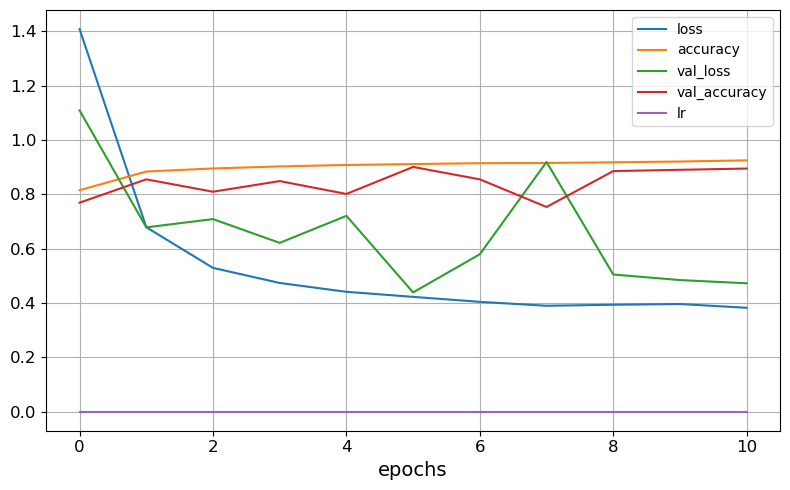

In [64]:
# Graficar
pd.DataFrame(history5.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 1)
plt.xlabel("epochs")
save_fig("T01_mnist_simple_dnn")
plt.show()

#### Análisis de las primeras épocas:

- Época 1:

    - Loss: 1.4076
    - Accuracy: 0.8152
    - Validation Loss: 1.1089
    - Validation Accuracy: 0.7693

Observación: La red comienza con una precisión relativamente alta en el conjunto de entrenamiento (81.52%) y una pérdida considerablemente baja en comparación con la validación. El modelo tiene más dificultad al generalizar a los datos de validación (76.93%).
    

- Época 2:

    - Loss: 0.6790
    - Accuracy: 0.8839
    - Validation Loss: 0.6786
    - Validation Accuracy: 0.8551
    
Observación: El modelo mejora tanto en la precisión de entrenamiento como en la validación. La diferencia entre la pérdida de entrenamiento y validación comienza a reducirse, lo que indica que el modelo está aprendiendo a generalizar mejor.


- Época 3:

    - Loss: 0.5295
    - Accuracy: 0.8951
    - Validation Loss: 0.7089
    - Validation Accuracy: 0.8096

Observación: Aunque la precisión de entrenamiento sigue mejorando, la precisión en validación ha disminuido ligeramente, lo que sugiere que el modelo puede estar empezando a sobreajustarse a los datos de entrenamiento.


- Épocas 4-7:

Observación: A medida que avanzan las épocas, se observa que la precisión en el conjunto de entrenamiento sigue aumentando (hasta 91.45% en la época 7), pero la validación fluctúa, alcanzando una precisión máxima de 90.07% en la época 6, pero volviendo a caer en la época 8 y 9. Este comportamiento es típico de modelos que comienzan a sobreajustarse a los datos de entrenamiento, especialmente cuando no se utiliza suficiente regularización o se emplean demasiadas épocas.


- Época 8:

    - Loss: 0.3939
    - Accuracy: 0.9177
    - Validation Loss: 0.9190
    - Validation Accuracy: 0.7535

Observación: En la época 8, el modelo muestra una fuerte disminución en el rendimiento de validación, con una gran diferencia en la pérdida y precisión entre entrenamiento y validación. Este puede ser un indicador de sobreajuste.


#### Early Stopping:

El EarlyStopping se activó en la época 11, debido a que no hubo mejora en la precisión de validación durante varias épocas consecutivas. Esto es una señal clara de que el modelo dejó de mejorar en el conjunto de validación y podría haber comenzado a sobreajustarse, lo que es la razón por la que el entrenamiento se detuvo antes de completar las 25 épocas.

#### Consideraciones:

- Sobreajuste: A pesar de los intentos de regularización, parece que el modelo todavía muestra signos de sobreajuste a partir de la época 7. Esto es común cuando el modelo tiene demasiadas capacidades (por ejemplo, muchas capas o neuronas) y no se ha regularizado lo suficiente.

- Regularización L2: La regularización L2 aplicada en las capas Conv2D y Dense parece estar funcionando parcialmente, pero tal vez sea necesario aumentar el factor de regularización (por ejemplo, aumentar el valor de 0.01) o probar con técnicas adicionales como Dropout o L1 regularization para evitar el sobreajuste aún más.

#### Siguientes pasos:

- Probar con mayor regularización L2: Podrías probar con un valor más alto para l2 (por ejemplo, 0.1) o añadir otras técnicas de regularización, como Dropout, en capas específicas.

- Más épocas con control de sobreajuste: Aunque EarlyStopping ha detenido el entrenamiento, puedes intentar más épocas con configuraciones de regularización más fuertes para mejorar el rendimiento.

### (Opcional) Aumentando la profundidad de la red

**¡AHORA TÚ!**
- Para hacer este apartado se requiere utilizar la nube de cómputo o un ordenador potente configurados con GPUs
- Lo que tenemos hasta ahora no es una red suficientemente _"deep"_. Crea un modelo `model6` aumentando el número de capas convolucionales de la red `model4` y la profundidad de la red (número de filtros de convolución).   
  - Deberías aumentar el número de channels en las capas más profundas de la red, ¿sabes contestar por qué?.
   - Observa que también puedes aumentar el número de neuronas en la capa _hidden_ de perceptrón multicapa (MLP) que hay al final de la red.
   - Controla el número de parámetros entrenables y número de capas en un tamaño manejable para el equipo que estás utilizando.
   - No utilices regularización L2 en este experimento si tu ordenador es demasiado lento.
   - Recuerda que puedes añadir _callbacks_ para variar el _learning rate_ dinámicamente.
   - Lanza el entrenamiento para un número de _epochs_ elevado (por ejemplo 50) y recuerda que puedes utilizar _early stopping_ ajustando el parámetro _patience_.
- A ver si puedes obtener un resultado cercano a `val_accuracy` en torno a 93%... ¡o mejor aún!

## Ampliación

- Blog towardsdatascience: The 4 Convolutional Neural Network Models That Can Classify Your Fashion Images

https://towardsdatascience.com/the-4-convolutional-neural-network-models-that-can-classify-your-fashion-images-9fe7f3e5399d
- Fashion MNIST benchmark

https://paperswithcode.com/sota/image-classification-on-fashion-mnist